<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Standard-Data-Science-Packages" data-toc-modified-id="Import-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Standard Data Science Packages</a></span><ul class="toc-item"><li><span><a href="#Set-Colorblind-Friendly-Palette" data-toc-modified-id="Set-Colorblind-Friendly-Palette-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Set Colorblind-Friendly Palette</a></span></li></ul></li><li><span><a href="#Load-and-Visualise-dPCR-Data" data-toc-modified-id="Load-and-Visualise-dPCR-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load and Visualise dPCR Data</a></span></li><li><span><a href="#Data-Analysis" data-toc-modified-id="Data-Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Analysis</a></span><ul class="toc-item"><li><span><a href="#Organise-Data" data-toc-modified-id="Organise-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Organise Data</a></span></li><li><span><a href="#Define-ACA-Model-(Neural-Network)" data-toc-modified-id="Define-ACA-Model-(Neural-Network)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Define ACA Model (Neural Network)</a></span></li><li><span><a href="#Train-and-Compute-Performance-(10-Fold-Cross-Val)" data-toc-modified-id="Train-and-Compute-Performance-(10-Fold-Cross-Val)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Train and Compute Performance (10-Fold Cross Val)</a></span></li><li><span><a href="#Visualise-AMCA-Coefficients" data-toc-modified-id="Visualise-AMCA-Coefficients-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Visualise AMCA Coefficients</a></span></li><li><span><a href="#Compute-Performance-as-a-Function-of-Training-Volume" data-toc-modified-id="Compute-Performance-as-a-Function-of-Training-Volume-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Compute Performance as a Function of Training Volume</a></span></li></ul></li></ul></div>

# Import Standard Data Science Packages

In [1]:
%load_ext autoreload
%autoreload
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import utilities as utils

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set Colorblind-Friendly Palette

In [2]:
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0,0.45,0.70),
                                                (0.9, 0.6, 0.0),
                                                (0.0, 0.60, 0.50),
                                                (0.8, 0.4, 0),
                                                (0.35, 0.7, 0.9),
                                                (0.8, 0.6, 0.7),
                                                (0,0,0),
                                                (0.5, 0.5, 0.5),
                                                (0.286, 0, 0.573)]])

# Load and Visualise dPCR Data

In [3]:
df_dpcr_ampl = pd.read_csv('Data/dPCR_Amplification_Curves.csv', 
                           index_col=0)

df_dpcr_ampl.columns = [float(col) if i > 6 else col for i, col in enumerate(df_dpcr_ampl.columns) ]

df_dpcr_ampl.head()

,Channel,PrimerMix,Target,Assay,Conc,Exp_id,MeltPeaks,1.0,2.0,3.0,...,36.0,37.0,38.0,39.0,40.0,41.0,42.0,43.0,44.0,45.0
0,panel27,PM9.8,mcr-1,G10,1000,20200520_03,87.692477,-0.002332,-0.001230,0.000142,...,0.581321,0.601197,0.618669,0.635126,0.649902,0.663124,0.674510,0.686901,0.697240,0.704513
1,panel27,PM9.8,mcr-1,G10,1000,20200520_03,87.780430,-0.001894,-0.000688,0.000313,...,0.575256,0.593098,0.610170,0.625578,0.639267,0.650257,0.661582,0.672329,0.680969,0.686617
2,panel27,PM9.8,mcr-1,G10,1000,20200520_03,87.590542,-0.000898,-0.001033,-0.000536,...,0.547249,0.568937,0.589255,0.606230,0.621452,0.634706,0.647114,0.658711,0.668511,0.674404
3,panel27,PM9.8,mcr-1,G10,1000,20200520_03,87.728431,-0.001766,-0.001131,-0.000071,...,0.594011,0.612835,0.631396,0.647228,0.662602,0.675371,0.687170,0.699071,0.709525,0.715469
4,panel27,PM9.8,mcr-1,G10,1000,20200520_03,87.844571,-0.001611,-0.000911,-0.000015,...,0.528289,0.548867,0.566421,0.582760,0.599386,0.614388,0.627660,0.642988,0.654468,0.662552


In [4]:
df_dpcr_ampl.shape

(58598, 52)

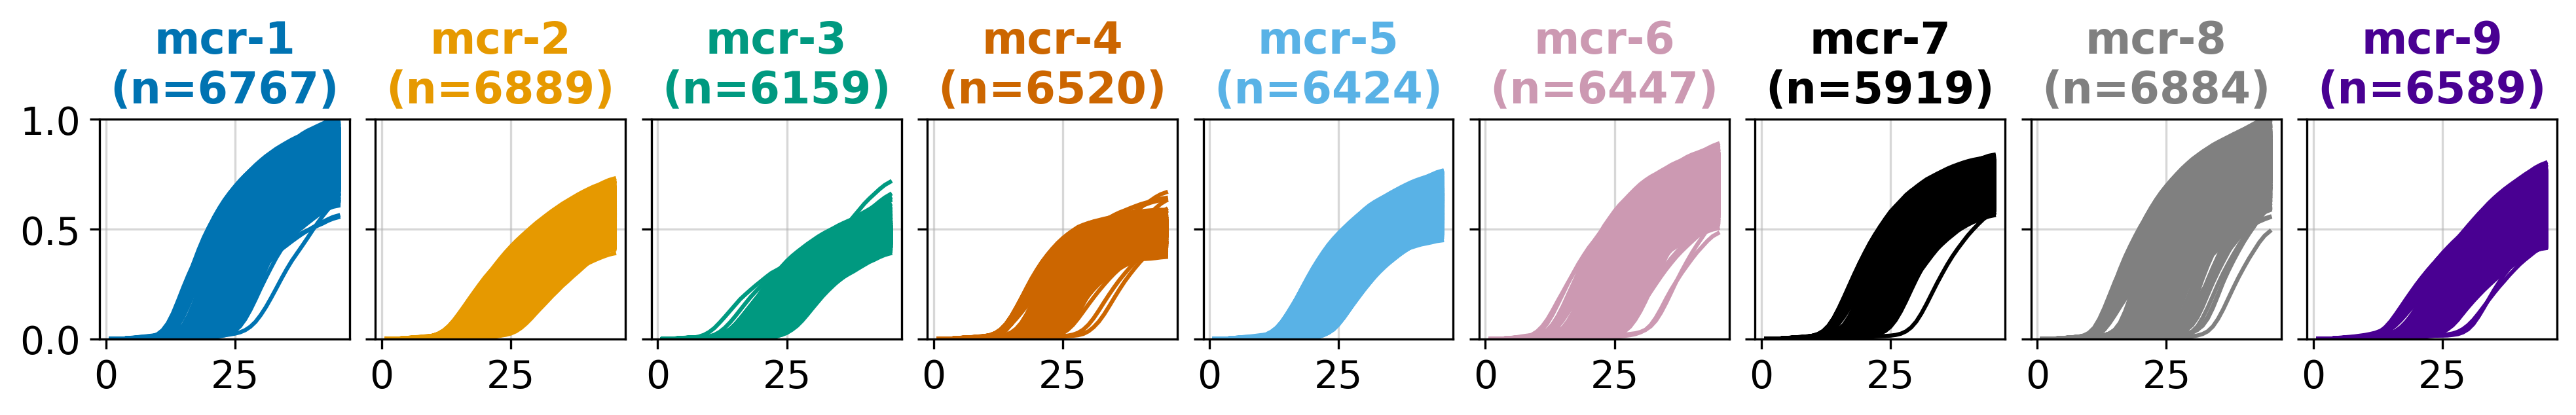

In [5]:
filename = 'Images/dPCR_amplification_curves.png'
utils.plot_amplification_curves(df_dpcr_ampl, NMETA=7, ylim=(0, 1.0), filename=filename)

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/0_4_AMCA Code/pyAMCA/utilities.py:168: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = sns.distplot(df_['MeltPeaks'], bins=bins, color=color, label=target)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/gk_code/0_4_AMCA Code/pyAMCA/utilities.py:168: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `

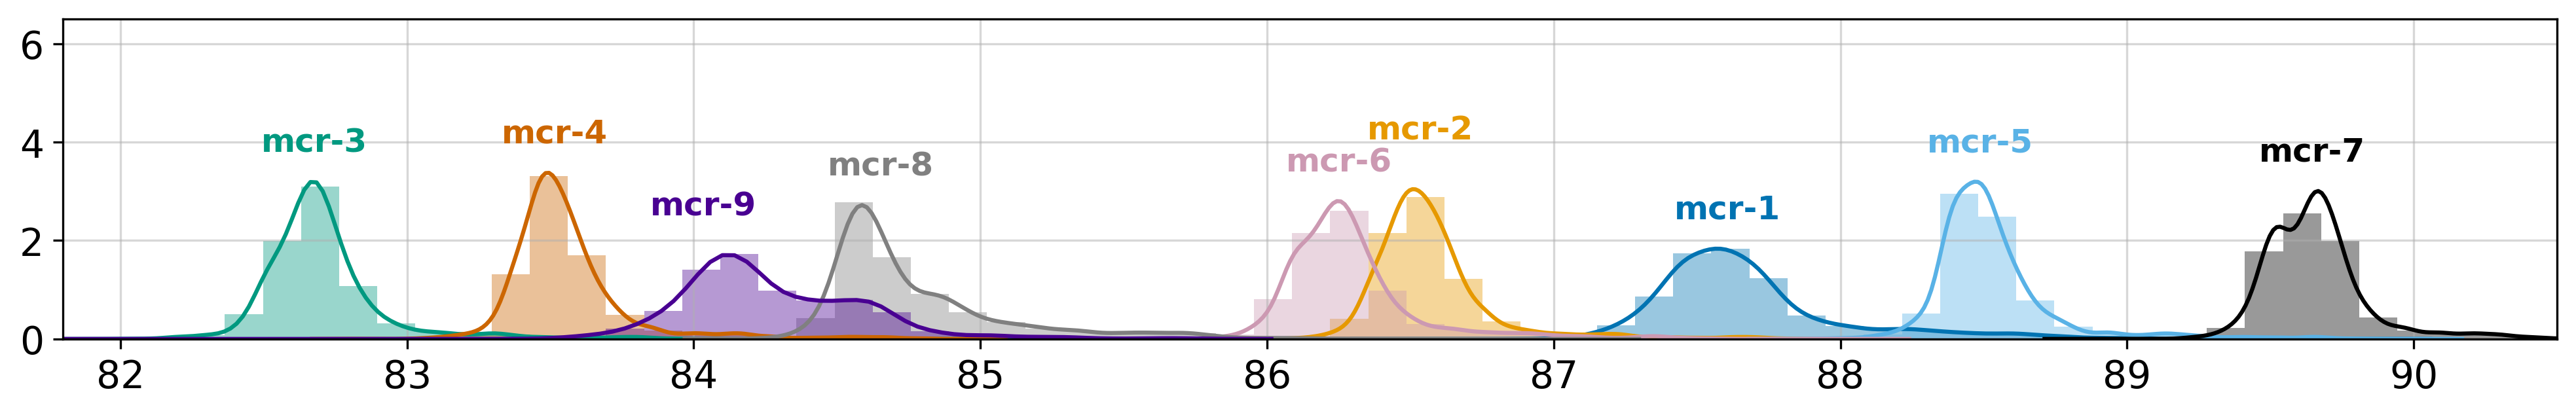

,mcr-1,mcr-2,mcr-3,mcr-4,mcr-5,mcr-6,mcr-7,mcr-8,mcr-9
Mean,87.672187,86.569879,82.705279,83.555294,88.526622,86.289772,89.666991,84.766404,84.267956
Median,87.605146,86.534407,82.675543,83.515290,88.487329,86.250338,89.646103,84.651842,84.204608
MaxLikelihood,87.563063,86.507450,82.662943,83.495274,88.467427,86.243725,89.667118,84.587243,84.099948
Std,0.325486,0.207487,0.222677,0.206108,0.212596,0.233627,0.209102,0.314641,0.319109
IQR,0.293899,0.176161,0.166288,0.161307,0.170687,0.197358,0.189916,0.296724,0.405873


In [6]:
filename = 'Images/dPCR_melting_peaks.png'
utils.plot_melt_peak_distributions(df_dpcr_ampl, filename=filename)

In [7]:
df_dpcr_melt = pd.read_csv('Data/dPCR_Melting_Curves.csv', 
                           index_col=0)

df_dpcr_melt.head()

,Channel,PrimerMix,Target,Assay,Conc,Exp_id,65.0,65.5,66.0,66.5,...,92.0,92.5,93.0,93.5,94.0,94.5,95.0,95.5,96.0,96.5
0,panel27,PM9.8,mcr-1,G10,1000,20200520_03,0.001309,0.009056,0.008263,0.008422,...,0.000130,0.000279,0.000479,0.000539,0.000563,0.000548,0.000543,0.000496,0.000613,0.000867
1,panel27,PM9.8,mcr-1,G10,1000,20200520_03,0.000656,0.006245,0.007456,0.008649,...,0.000617,0.000693,0.000601,0.000344,0.000172,0.000239,0.000276,0.000196,0.000337,-0.000957
2,panel27,PM9.8,mcr-1,G10,1000,20200520_03,0.001303,0.009023,0.008302,0.008445,...,0.000749,0.000772,0.000756,0.000660,0.000479,0.000456,0.000428,0.000294,0.000290,-0.000240
3,panel27,PM9.8,mcr-1,G10,1000,20200520_03,0.000558,0.007052,0.009496,0.009808,...,0.000416,0.000363,0.000532,0.000630,0.000607,0.000617,0.000525,0.000558,0.000443,0.001078
4,panel27,PM9.8,mcr-1,G10,1000,20200520_03,0.001142,0.008036,0.007470,0.007846,...,0.000312,0.000153,0.000120,0.000070,0.000138,0.000243,0.000248,0.000192,0.000053,0.000092


In [8]:
df_dpcr_melt.shape

(58664, 70)

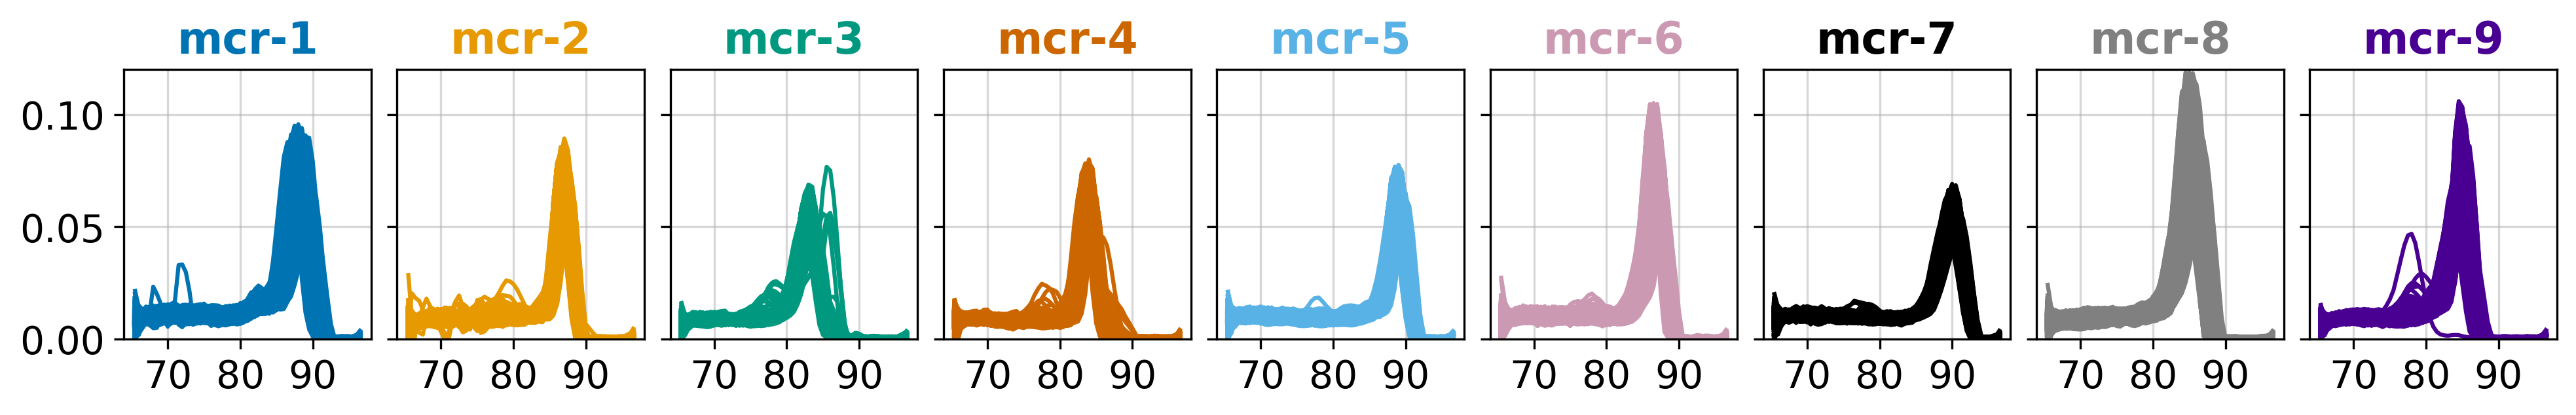

In [9]:
filename = 'Images/dPCR_melting_curves.png'
utils.plot_melt_curves(df_dpcr_melt, NMETA=7, ylim=(0, 0.12), filename=filename)

# Data Analysis
## Organise Data

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV

X_AC = df_dpcr_ampl.iloc[:, 7:].values
X_MC = df_dpcr_ampl.loc[:, ['MeltPeaks']].values
X_FFI = X_AC[:,[-1]]

encoder = LabelEncoder()
encoder.fit(df_dpcr_ampl['Target'])
ytrue = encoder.transform(df_dpcr_ampl['Target'])

X_MC.shape, X_AC.shape, X_FFI.shape, ytrue.shape

((58598, 1), (58598, 45), (58598, 1), (58598,))

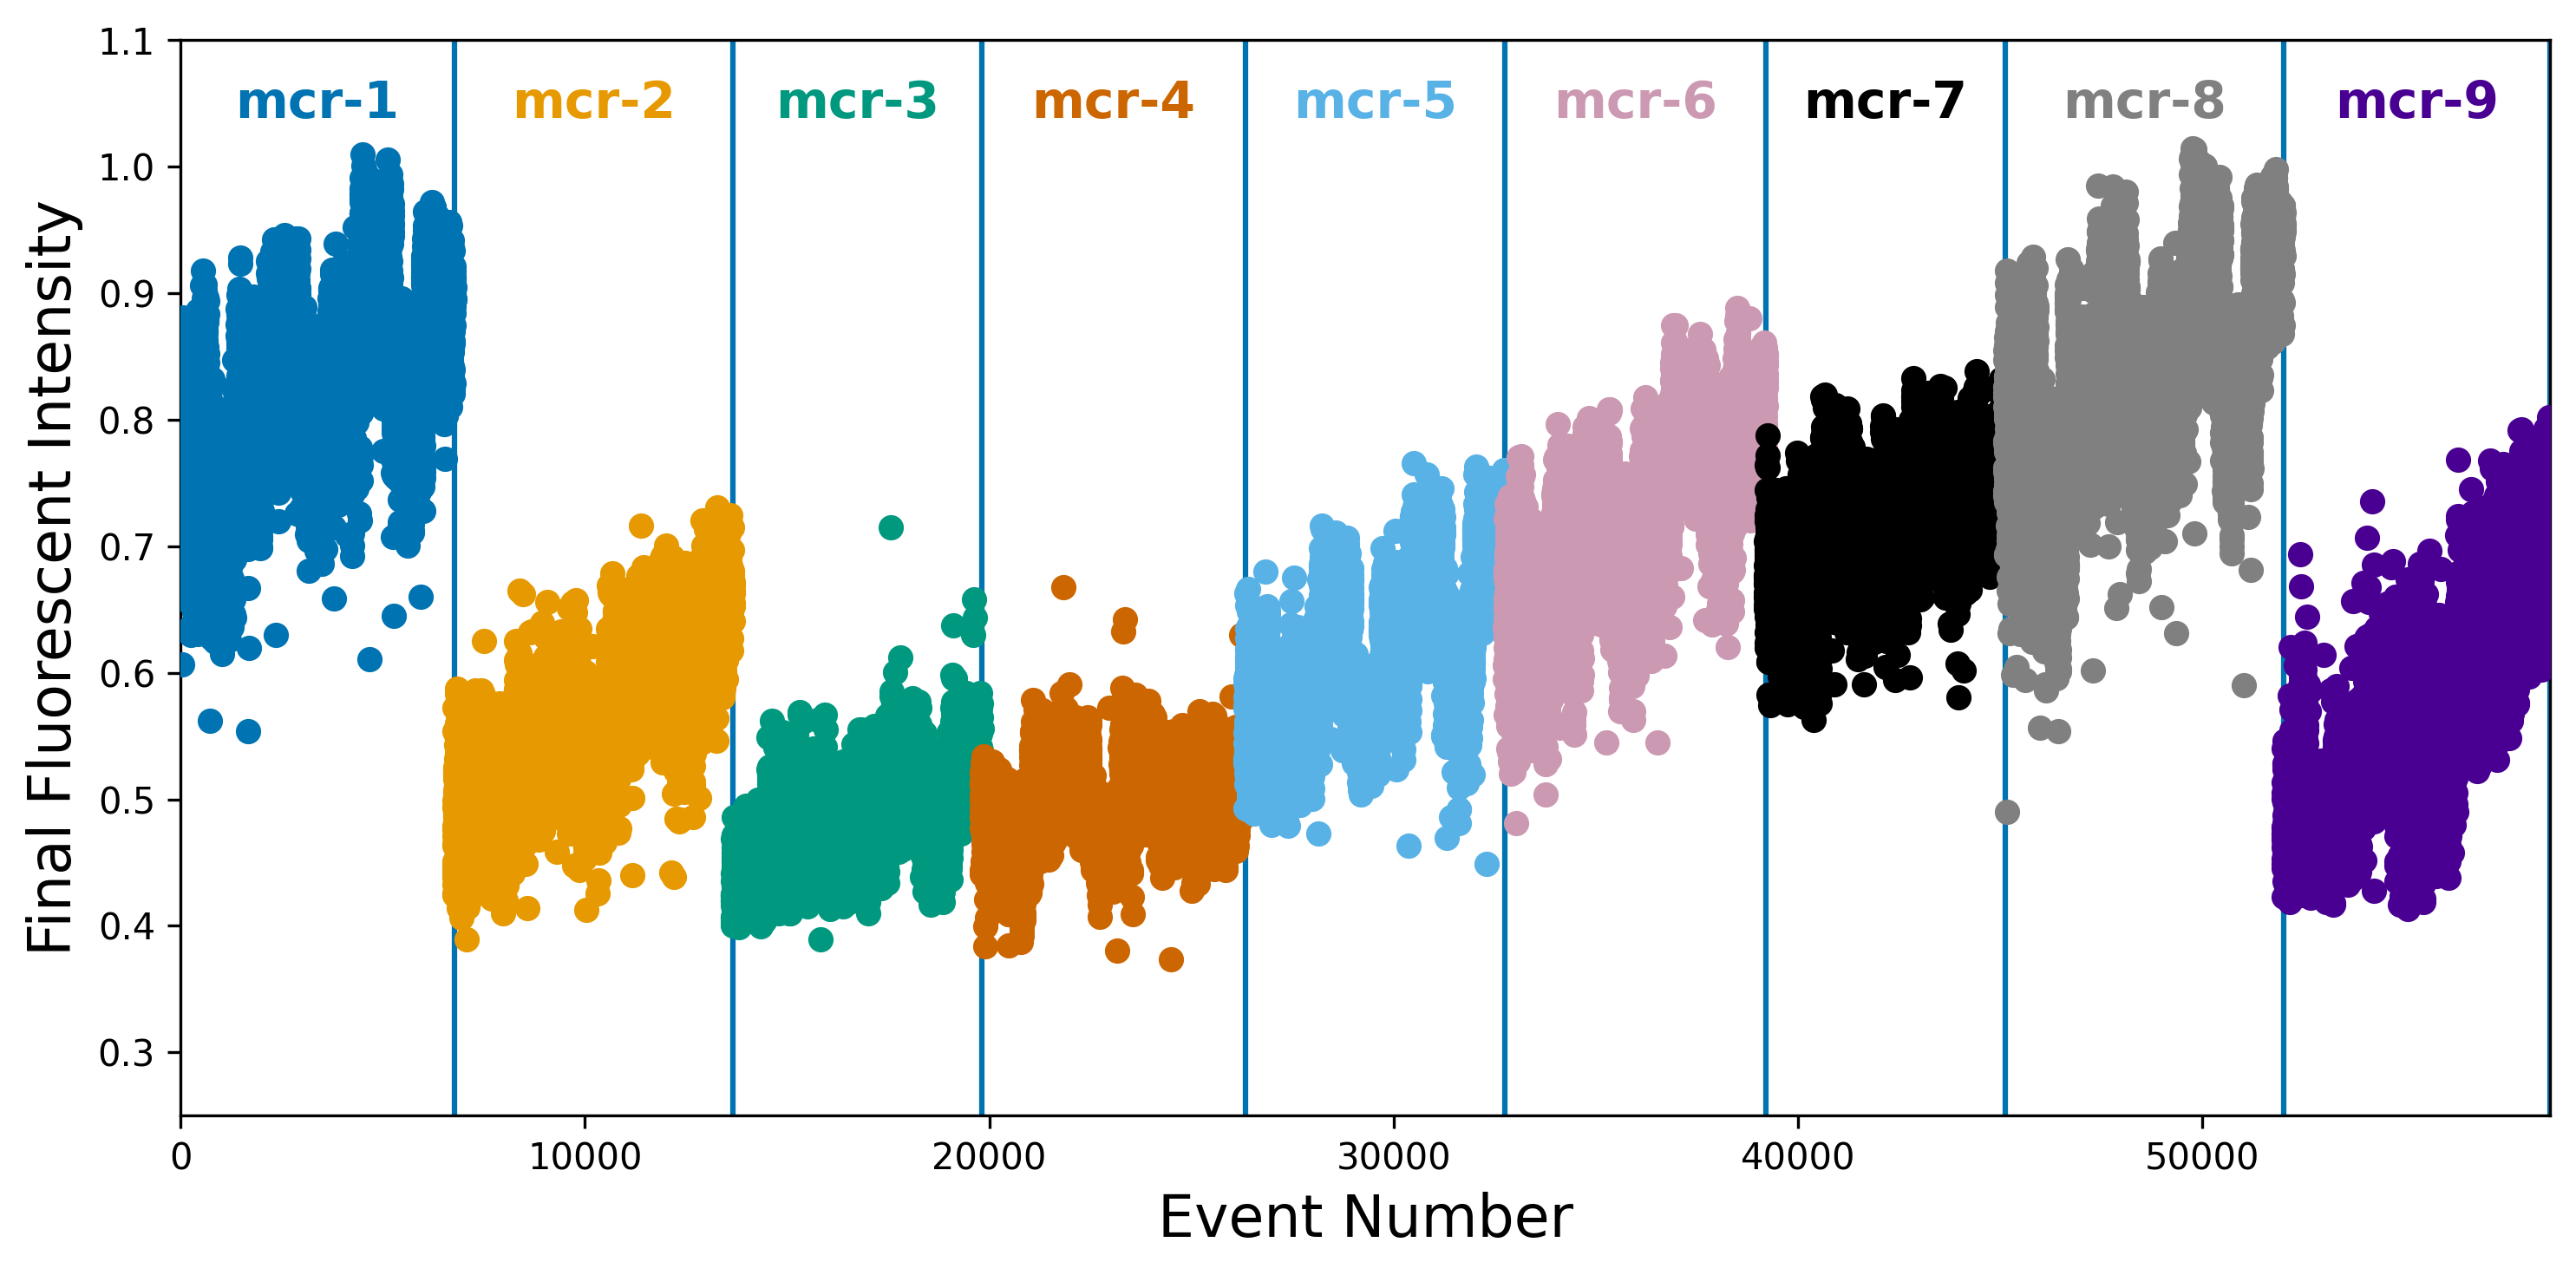

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)

cnt = 0
for i in range(9):
    idx = ytrue==i
    ax.scatter(np.arange(np.sum(idx)) + cnt, X_FFI[idx], color=f'C{i}', zorder=100)
    
    ax.text(cnt + np.sum(idx)/2, 1.05, encoder.classes_[i], color=f'C{i}', fontsize=14, weight='bold',
            horizontalalignment='center', verticalalignment='center')
    
    cnt += np.sum(idx)
    
    ax.vlines(cnt, 0.25, 1.1)
    
    
ax.set_xlim((0, len(X_FFI)))
ax.set_ylim((0.25, 1.1))

ax.set_ylabel('Final Fluorescent Intensity', fontsize=16)
ax.set_xlabel('Event Number', fontsize=16)

# ax.grid(True)

plt.tight_layout()
plt.savefig('Images/dPCR_FFI_Dist.png')
plt.show()

## Define ACA Model (Neural Network)

In [12]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

class myWrapper(KerasClassifier):
    # def predict(self, X):
    #     return self.model.predict(X).argmax(axis=1)
    
    # def predict_proba(self, X):
    #     return self.model.predict(X)
    pass

display(f'TF VERSION: {tf.__version__}')

def create_model(): # 70% WE USED FOR THE FIRST TIME TNSOR BOARD
    # TIMESTEPS, CHANNELS
    inputs = tf.keras.layers.Input(shape=(45, 1))
    x = tf.keras.layers.Conv1D(16, 5, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(8, 3, activation='relu')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(9, activation='softmax')(x)
    model = tf.keras.models.Model(inputs=inputs, outputs=x)
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

tf_net = create_model()
tf_net.summary()

'TF VERSION: 2.21.0'

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 45, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 41, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 39, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 312)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         2,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305 (12.91 KB)

 Trainable params: 3,305 (12.91 KB)

 Non-trainable params: 0 (0.00 B)

## Train and Compute Performance (10-Fold Cross Val)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

N_SPLITS = 10

kfolds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
splits = kfolds.split(X_AC, ytrue)

y_trues_ = []

y_preds_AC_ = []
y_preds_AC_kNN_ = []

y_preds_MC_ = []

y_preds_FFI_ = []

y_preds_AMCA_ = []
y_preds_AMCA_kNN_ = []

for i, (train_index, test_index) in enumerate(tqdm(splits, total=N_SPLITS)):

    X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
    X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
    X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]
    
    y_train, y_test = ytrue[train_index], ytrue[test_index]
    y_trues_.append(y_test)

    ########## create/train model for AC ##########
    clf_AC = myWrapper(build_fn=create_model, 
                            epochs=1000, 
                            batch_size=512, 
                            shuffle=True,
                            verbose=False)
    clf_AC.fit(X_AC_train, y_train)
    clf_AC_proba = clf_AC.predict_proba(X_AC_train)
    y_preds_AC_.append( clf_AC.predict(X_AC_test) )
    
    ########## create/train model for AC with KNN##########
    clf_AC_kNN = KNeighborsClassifier(n_neighbors=10)
    clf_AC_kNN.fit(X_AC_train, y_train)
    clf_AC_kNN_proba = clf_AC_kNN.predict_proba(X_AC_train)
    y_preds_AC_kNN_.append(clf_AC_kNN.predict(X_AC_test))

    ########## create/train model for MC ##########    
    clf_MC = LogisticRegression(max_iter=1000)
    clf_MC.fit(X_MC_train, y_train)
    clf_MC_proba = clf_MC.predict_proba(X_MC_train)
    y_preds_MC_.append(clf_MC.predict(X_MC_test))

    ########## create/train model for FFI ##########
    clf_FFI = LogisticRegression(max_iter=1000)
    clf_FFI.fit(X_FFI_train, y_train)
    y_preds_FFI_.append(clf_FFI.predict(X_FFI_test))

    ########## create/train model for AMCA ##########
    X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)
    X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                   clf_AC.predict_proba(X_AC_test)), axis=1)
    
    clf_AMCA = LogisticRegression(max_iter=1000, fit_intercept=False)
    clf_AMCA.fit(X_AMCA_train, y_train)
    y_preds_AMCA_.append(clf_AMCA.predict(X_AMCA_test))

    ########## create/train model for AMCA kNN ##########
    X_AMCA_kNN_train = np.concatenate((clf_MC_proba, clf_AC_kNN_proba), axis=1)
    X_AMCA_kNN_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                   clf_AC_kNN.predict_proba(X_AC_test)), axis=1)
    
    clf_AMCA_kNN = LogisticRegression(max_iter=1000, fit_intercept=False)
    clf_AMCA_kNN.fit(X_AMCA_kNN_train, y_train)
    y_preds_AMCA_kNN_.append(clf_AMCA_kNN.predict(X_AMCA_kNN_test))

    
y_trues = np.concatenate(y_trues_)

y_preds_AC = np.concatenate(y_preds_AC_)
y_preds_AC_kNN = np.concatenate(y_preds_AC_kNN_)
y_preds_MC = np.concatenate(y_preds_MC_)
y_preds_FFI = np.concatenate(y_preds_FFI_)
y_preds_AMCA = np.concatenate(y_preds_AMCA_)
y_preds_AMCA_kNN = np.concatenate(y_preds_AMCA_kNN_)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 10%|█         | 1/10 [03:02<27:25, 182.81s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
 20%|██        | 2/10 [06:05<24:21, 182.65s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/

In [15]:
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from scipy.stats import bartlett, ttest_ind

acc_for_each_fold = lambda x: [accuracy_score(i, j) for i, j in zip(x, y_trues_)]

acc_dict = {'FFI': acc_for_each_fold(y_preds_FFI_),
            'ACA': acc_for_each_fold(y_preds_AC_),
            'ACA_kNN': acc_for_each_fold(y_preds_AC_kNN_),
            'MCA': acc_for_each_fold(y_preds_MC_),
            'AMCA': acc_for_each_fold(y_preds_AMCA_),
            'AMCA_kNN': acc_for_each_fold(y_preds_AMCA_kNN_),}
acc = pd.DataFrame(acc_dict)

normality_test = lambda x: sm.stats.lilliefors(x)[1]

variance_test = lambda x: bartlett(x, acc['AMCA'])[1]

ttest = lambda x: ttest_ind(x, acc['AMCA'], equal_var=False)[1]

statistics = lambda x: [np.mean(x), np.std(x), normality_test(x), variance_test(x), ttest(x)]

stats = pd.DataFrame({k: statistics(acc[k]) for k in acc.columns})

stats.index = ['Mean Acc.', 'Std Acc.', 'Normality p-val.', 'Equal Var. p-val', 'Ttest p-val']

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

stats

,FFI,ACA,ACA_kNN,MCA,AMCA,AMCA_kNN
Mean Acc.,0.3451,0.8043,0.8601,0.8933,0.9930,0.9928
Std Acc.,0.0050,0.0352,0.0046,0.0033,0.0011,0.0016
Normality p-val.,0.3016,0.8544,0.0247,0.5728,0.3163,0.1210
Equal Var. p-val,0.0001,0.0000,0.0002,0.0028,1.0000,0.2574
Ttest p-val,0.0000,0.0000,0.0000,0.0000,1.0000,0.7731


In [17]:
pd.DataFrame({'True': y_trues,'FFI': y_preds_FFI, 'ACA_ConvNN': y_preds_AC, 'ACA_kNN': y_preds_AC_kNN, 'MCA': y_preds_MC, 'AMCA': y_preds_AMCA, 'AMCA_kNN': y_preds_AMCA_kNN}).to_csv('Data/my_preds.csv')

In [ ]:
# np.save('Data/my_coeff', clf.coef_)

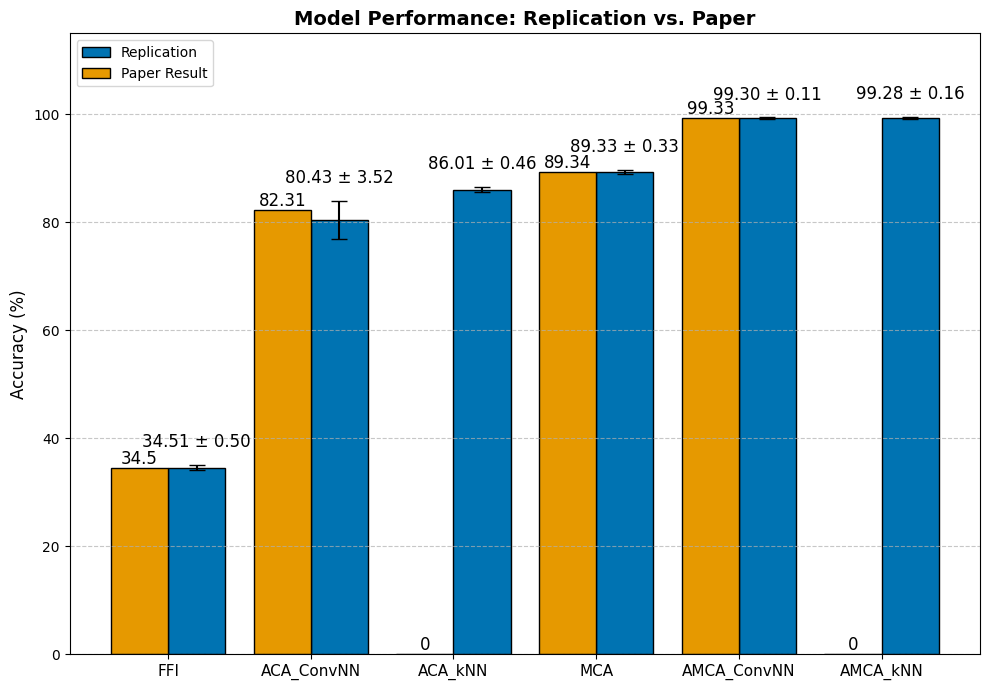

In [21]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI_, y_preds_AC_, y_preds_AC_kNN_, y_preds_MC_, y_preds_AMCA_, y_preds_AMCA_kNN_]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)',
          'Melting Curve Analysis',
          'Amplification and Melting Curve Analysis',
          'Amplification and Melting Curve Analysis (kNN)']
short_names = ['FFI', 'ACA_ConvNN', 'ACA_kNN', 'MCA', 'AMCA_ConvNN', 'AMCA_kNN']
paper_result = [34.50, 82.31, 0, 89.34, 99.33, 0]

accs_mean = []
accs_std = []
for yps in ypreds_methods:
    acc_temp = []
    for yp, y_tr in zip(yps, y_trues_):
        acc_temp.append(accuracy_score(y_tr, yp)*100)
    accs_mean.append(np.mean(acc_temp))
    accs_std.append(np.std(acc_temp))

# Labels for the replication bars
custom_labels = [f'{a:.2f} ± {s:.2f}' for a, s in zip(accs_mean, accs_std)]

# Plotting setup
x = np.arange(len(short_names))
width = 0.4  # Width of each bar

fig, ax = plt.subplots(figsize=(10, 7))

# Plot Replication bars (with error bars)
bars_rep = ax.bar(x + width/2, accs_mean, width, yerr=accs_std, capsize=6, 
                  edgecolor='black', label='Replication')

# Plot Paper bars
bars_paper = ax.bar(x - width/2, paper_result, width, 
                    edgecolor='black', label='Paper Result')

# Add labels on top of bars
ax.bar_label(bars_paper, padding=0, fontsize=12)
ax.bar_label(bars_rep, labels=custom_labels, padding=10, fontsize=12)


# Formatting
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Performance: Replication vs. Paper', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, 115) 
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [23]:
print(short_names)
print(paper_result)
print(accs_mean)
print(accs_std)

['FFI', 'ACA_ConvNN', 'ACA_kNN', 'MCA', 'AMCA_ConvNN', 'AMCA_kNN']
[34.5, 82.31, 0, 89.34, 99.33, 0]
[np.float64(34.511411224061234), np.float64(80.42600689584066), np.float64(86.01319139715045), np.float64(89.32728476419989), np.float64(99.30031653994001), np.float64(99.28154783021017)]
[np.float64(0.49999922392977203), np.float64(3.521395763921658), np.float64(0.4627713383192835), np.float64(0.3267157472697195), np.float64(0.1073976909390987), np.float64(0.15906496641217882)]


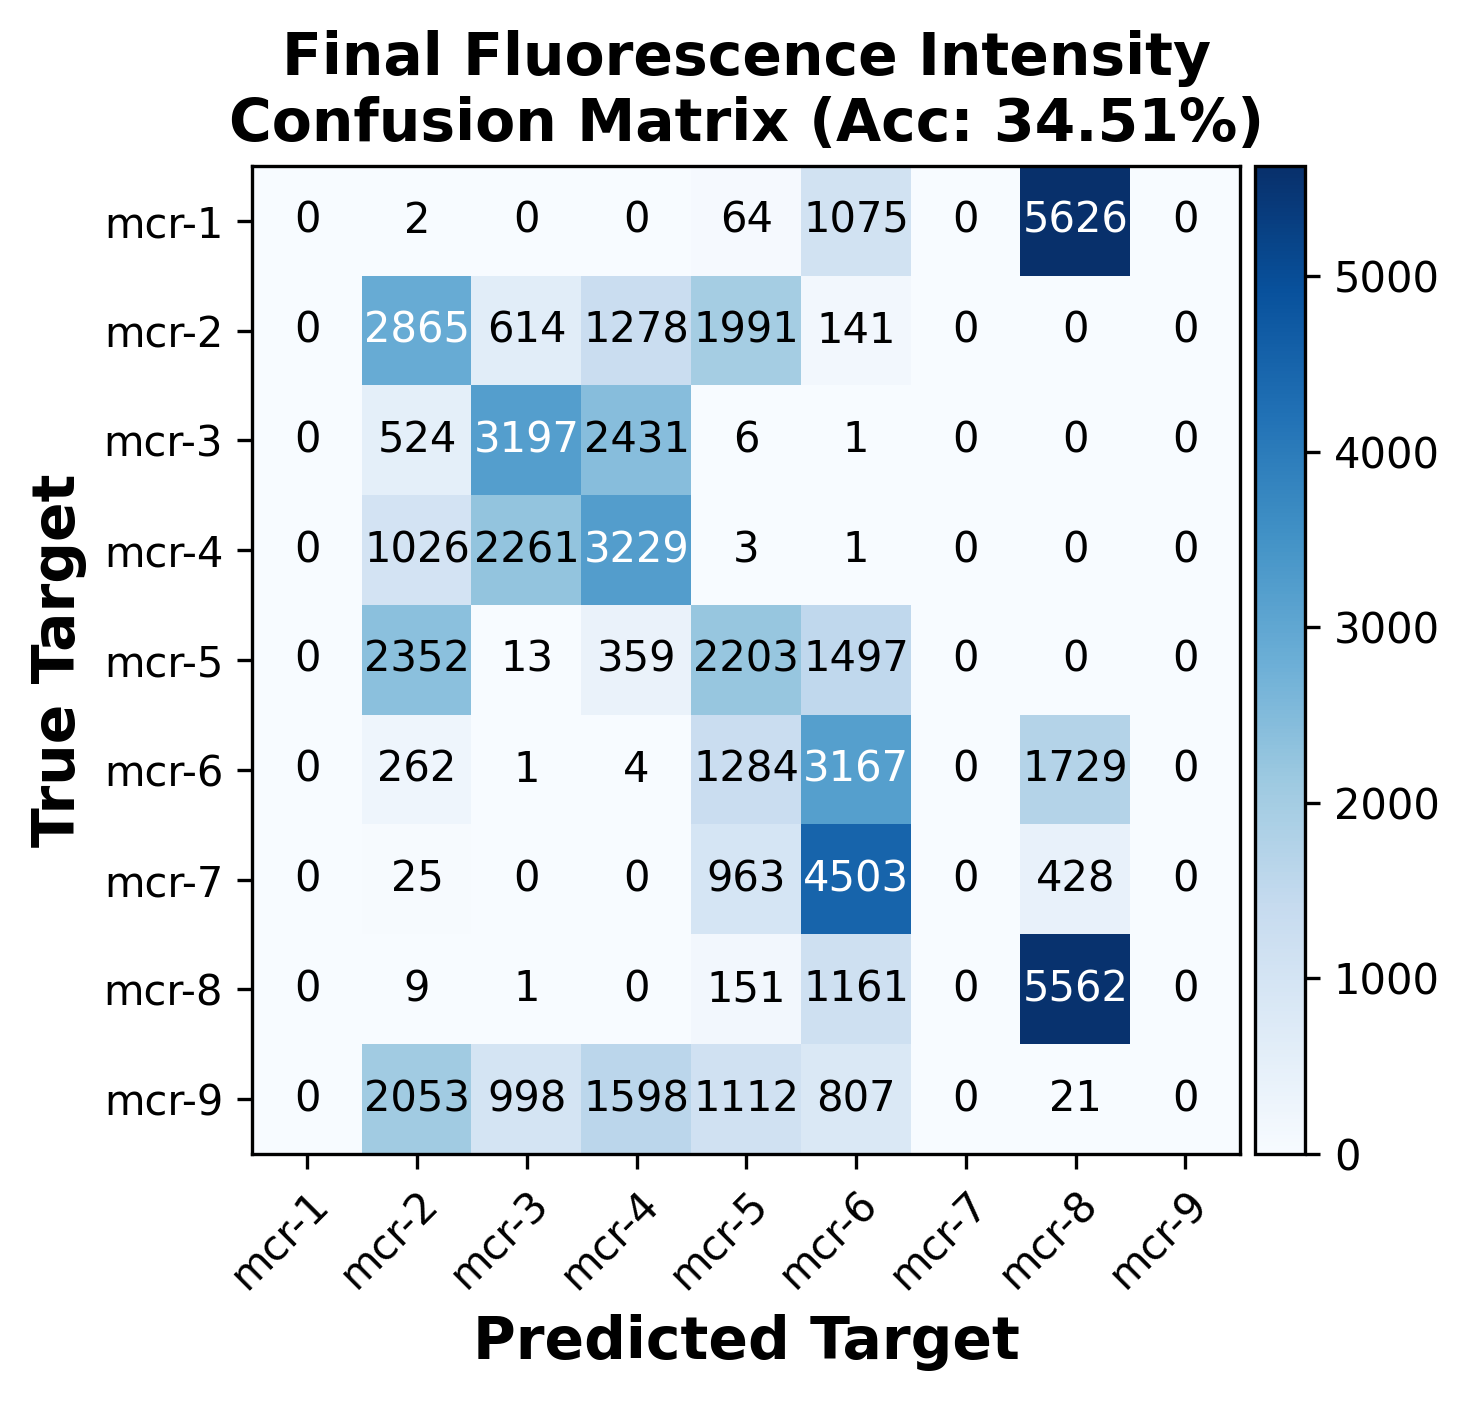

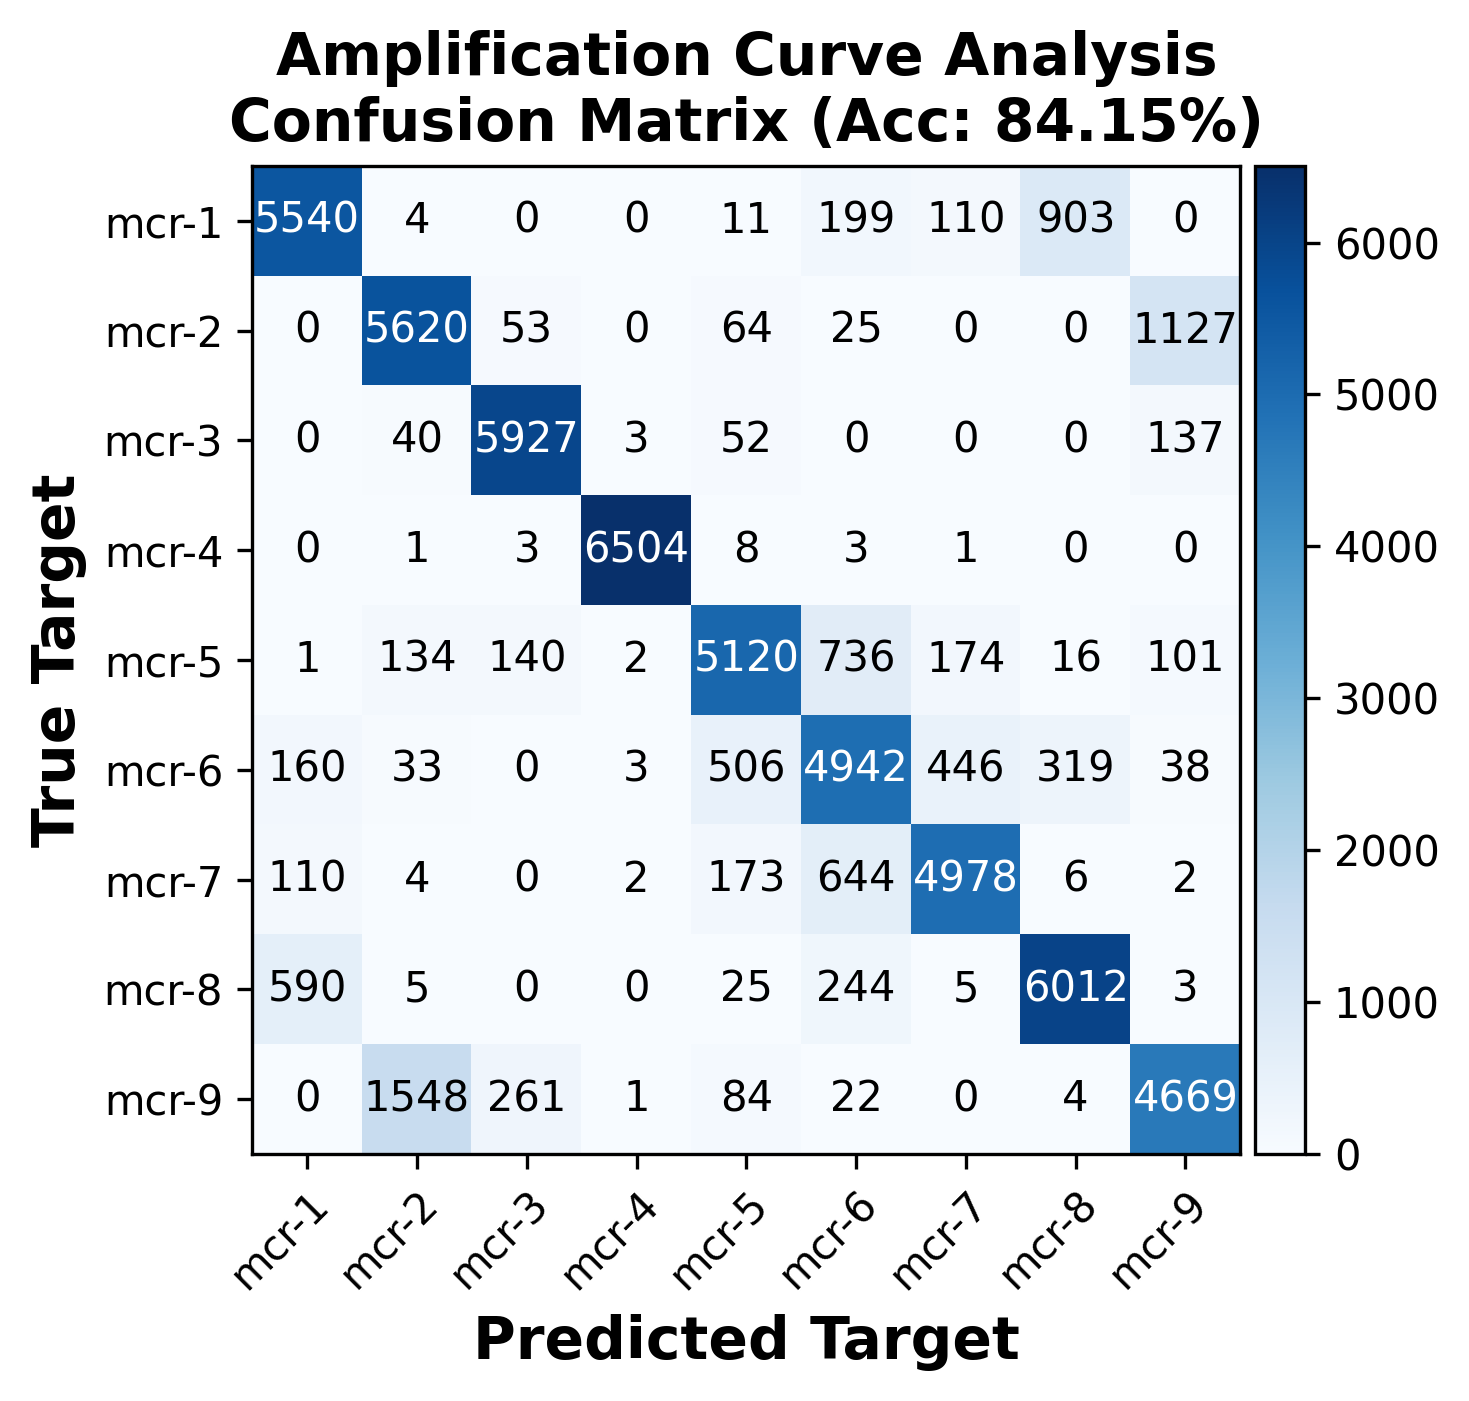

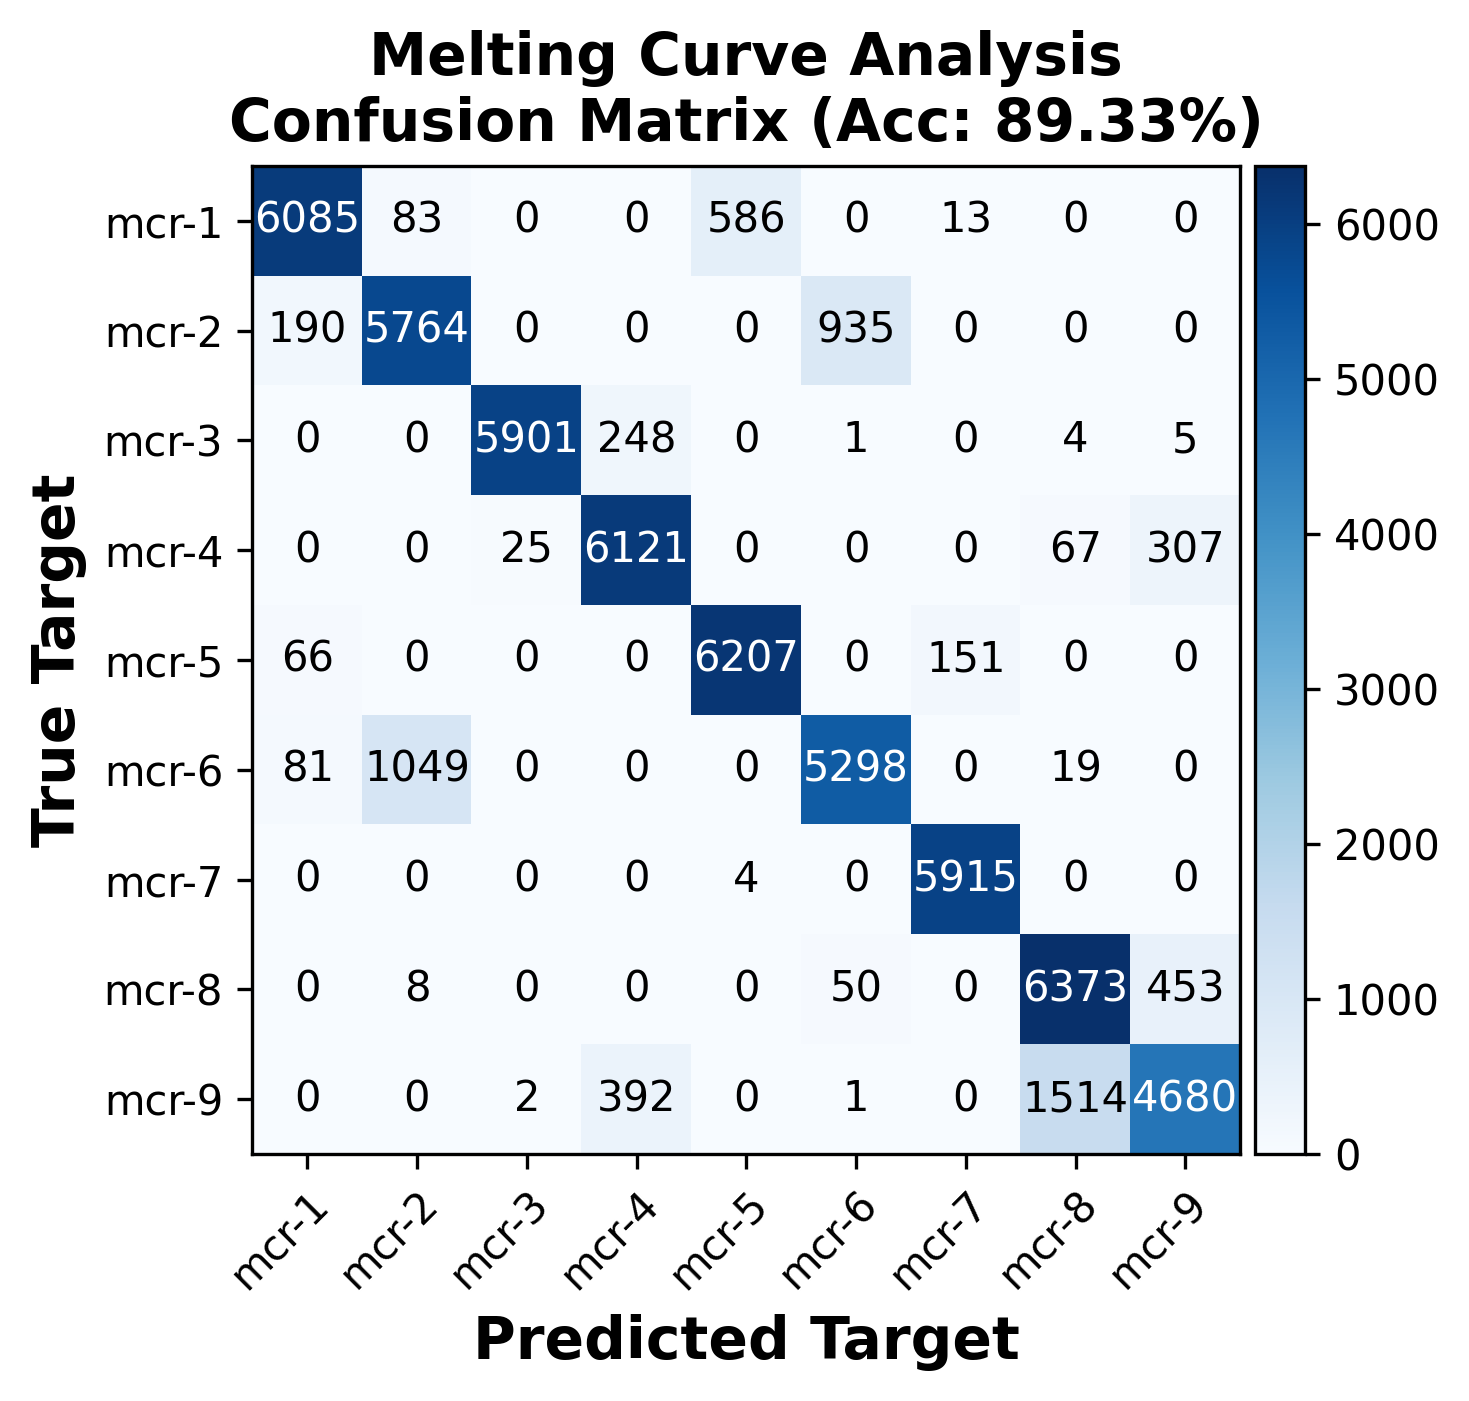

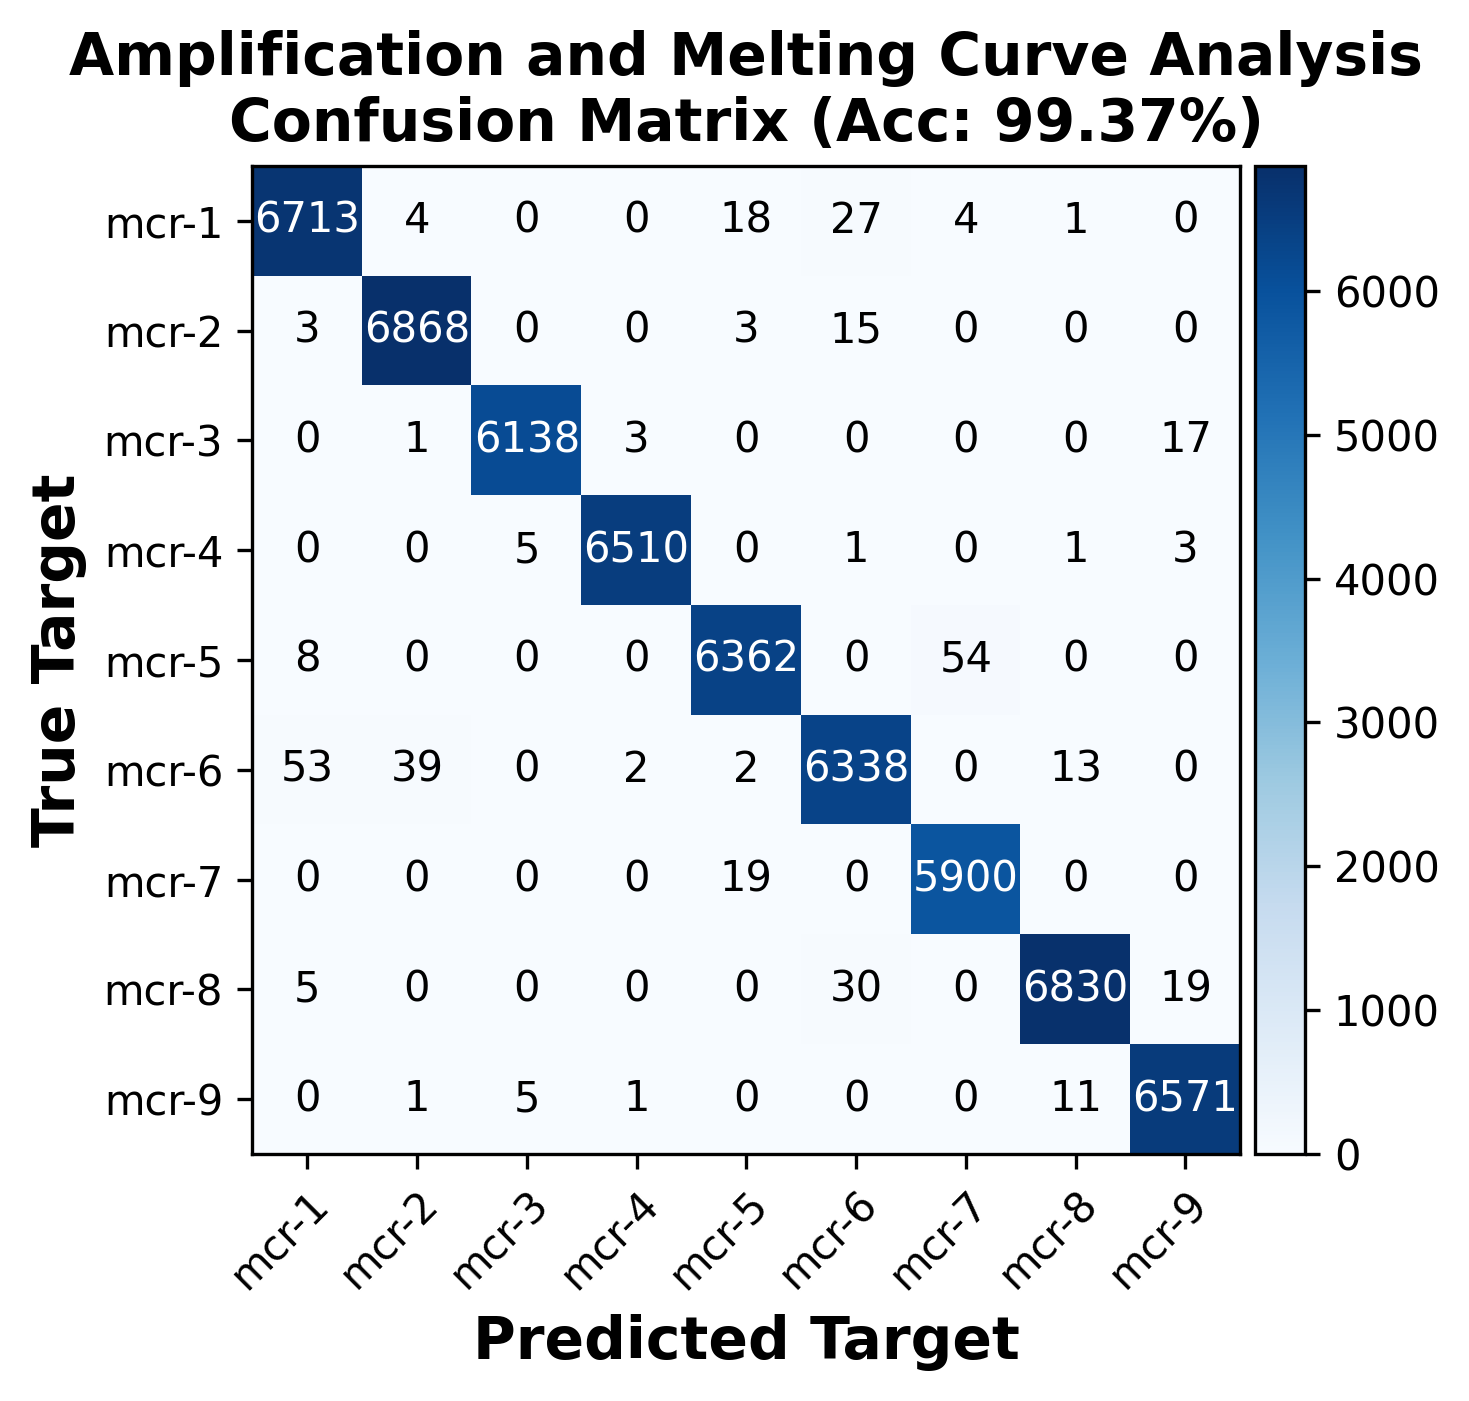

In [ ]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI, y_preds_AC, y_preds_AC_kNN, y_preds_MC, y_preds_AMCA, y_preds_AMCA_kNN]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)',
          'Melting Curve Analysis',
          'Amplification and Melting Curve Analysis',
          'Amplification and Melting Curve Analysis (kNN)']
short_names = ['FFI', 'ACA', 'ACA_kNN', 'MCA', 'AMCA', 'AMCA_kNN']

for yp, title, short_name in zip(ypreds_methods, titles, short_names):

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    utils.plot_confusion_matrix(y_trues, yp, classes, ax, normalize=False)
    ax.set_title(f'{title}\n'+ax.get_title(), fontsize=14, weight='bold')
    ax.set_ylabel('True Target', fontsize=14, weight='bold')
    ax.set_xlabel('Predicted Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}.pdf')
    plt.show()

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix

np.set_printoptions(precision=3, suppress=True)

a = 100*confusion_matrix(y_trues, y_preds, normalize='true')

a.sum(axis=1) - np.diagonal(a)

array([0.798, 0.305, 0.341, 0.153, 0.965, 1.691, 0.321, 0.784, 0.273])

## Visualise AMCA Coefficients

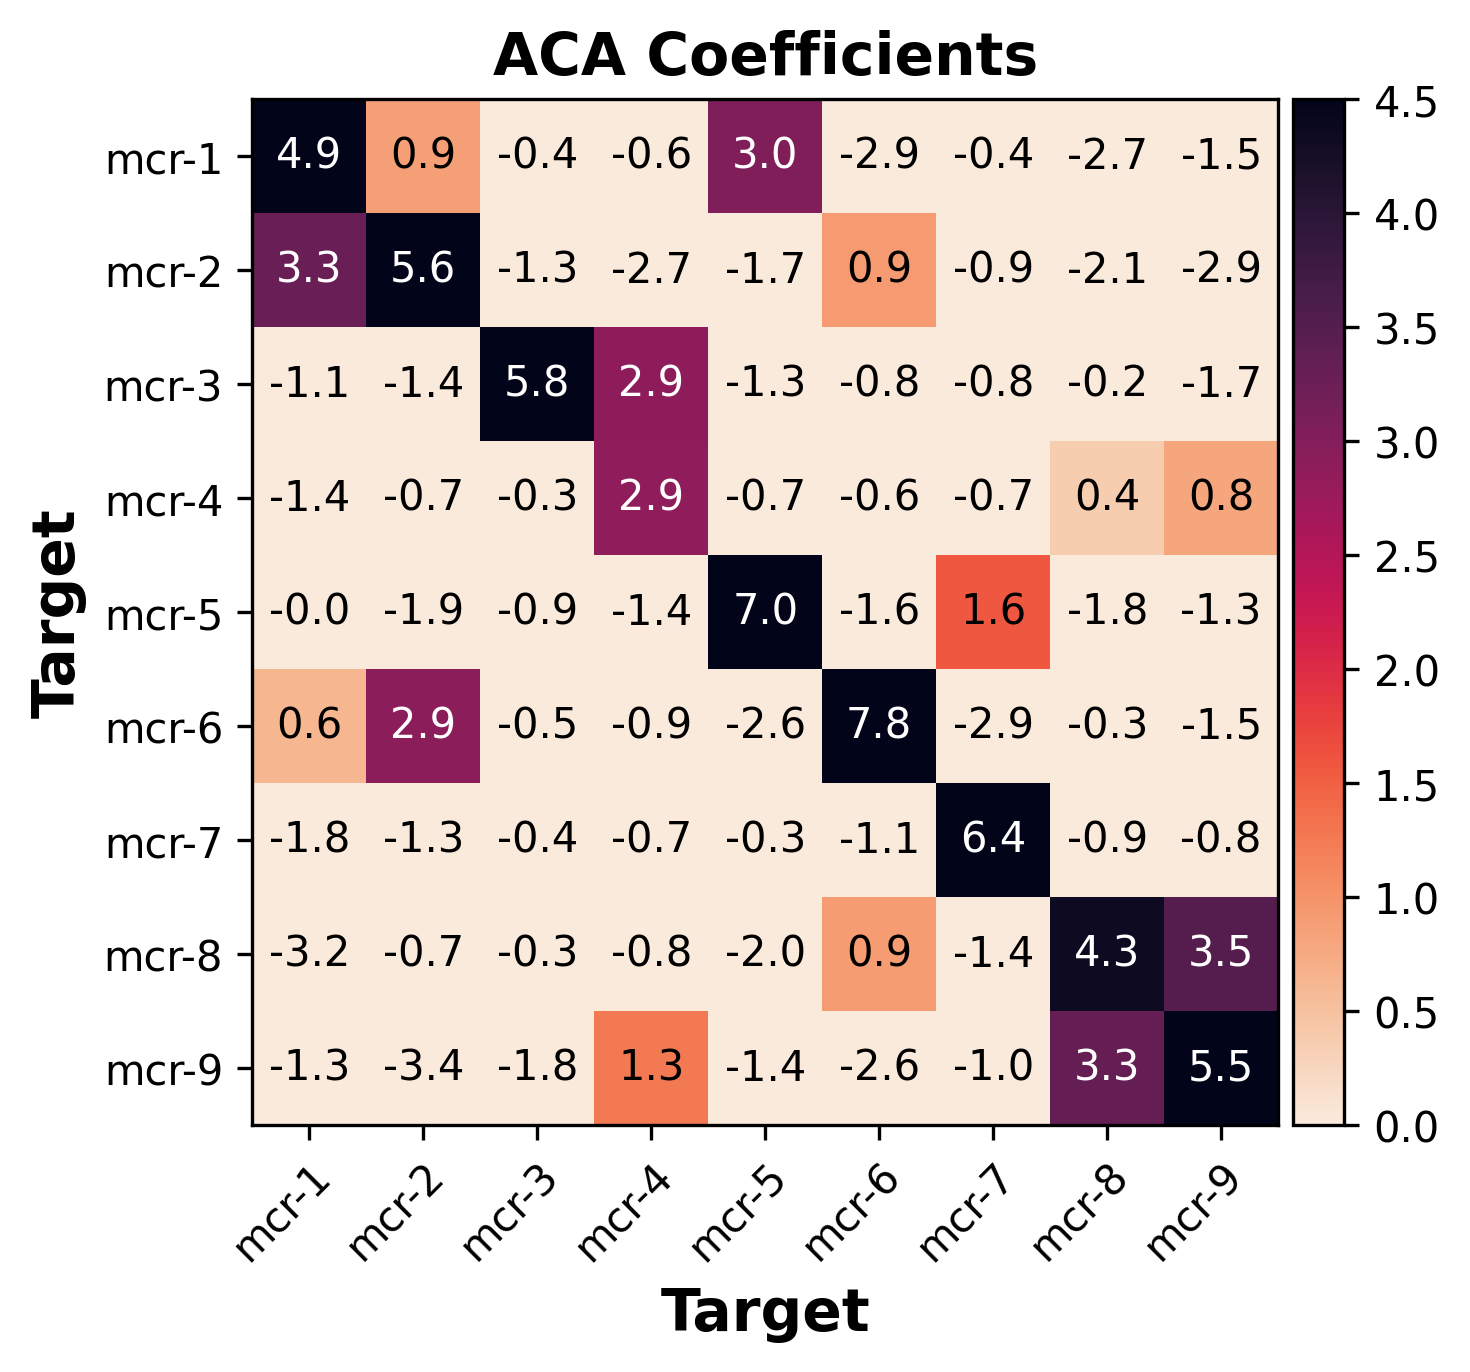

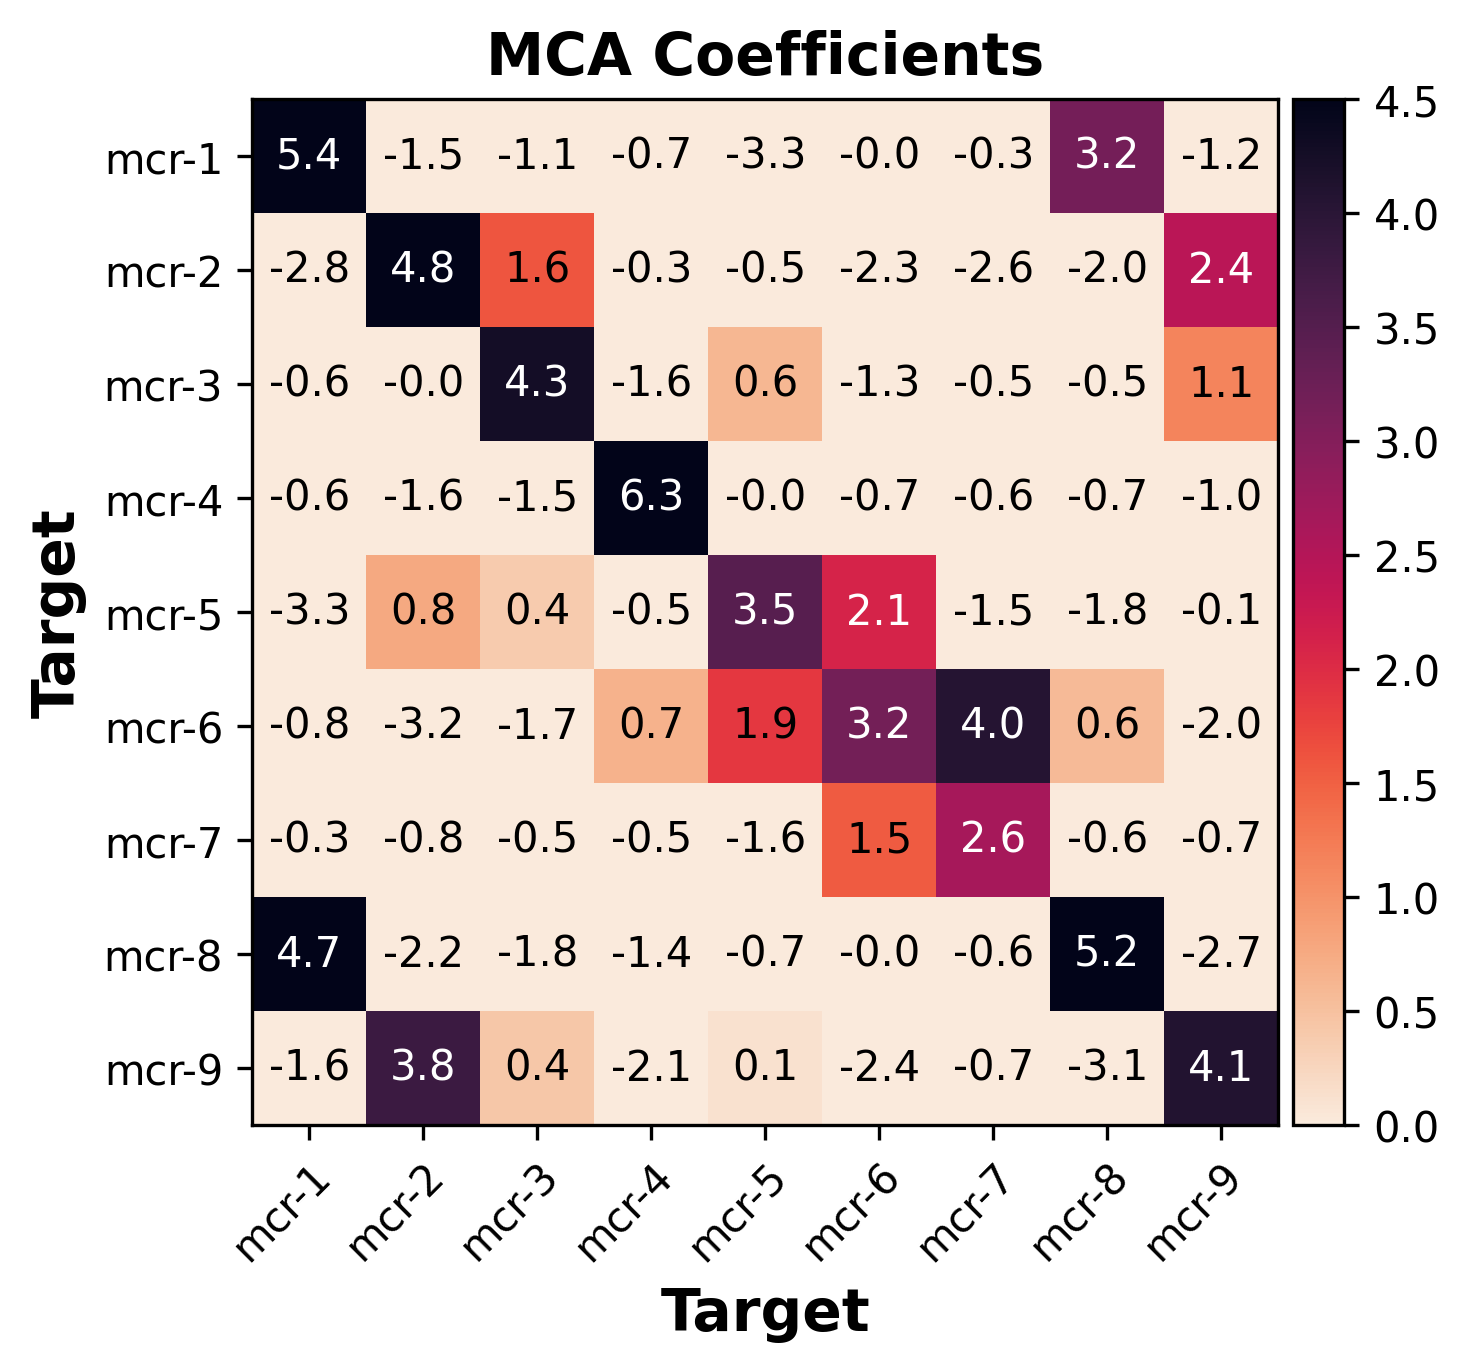

In [120]:
ACA_coef = clf.coef_[:,:9]
MCA_coef = clf.coef_[:,-9:]
    
coefs = [ACA_coef, MCA_coef]
short_names = ['ACA', 'MCA']
    
for coef, short_name in zip(coefs, short_names):
    
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    utils.my_heatmap(coef, ax, sns.cm.rocket_r)
    ax.set_title(f'{short_name} Coefficients', fontsize=14, weight='bold')
    ax.set_ylabel('Target', fontsize=14, weight='bold')
    ax.set_xlabel('Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}_coeffs.pdf')
    plt.show()

## Compute Performance as a Function of Training Volume

In [122]:
from sklearn.model_selection import StratifiedShuffleSplit
import datetime

n_total = len(X_AC)
assert len(X_AC)==len(X_MC)==len(X_FFI), "Something is wrong!"

n_repeat = 1
n_train_sizes = 20
test_size = 5000

train_size = (10**np.linspace(2, np.log10(n_total-test_size), num=n_train_sizes))/n_total
# train_size = np.linspace(50, n_total-test_size, num=n_train_sizes) / n_total

accuracy = pd.DataFrame(columns = ['Method', 'TrainSize', 'Train/Test', 'Accuracy', 'Repeat ID'])

for size in tqdm(train_size, desc='Train Size Split'):
    
    sss = StratifiedShuffleSplit(n_splits=n_repeat, test_size=test_size/n_total, random_state=5)

    for split_id, (train_index, test_index) in tqdm(enumerate(sss.split(X_AC, ytrue)), 
                                                    total=n_repeat, desc='Repeat', leave=False):
        
        X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
        X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
        X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]

        y_train, y_test = ytrue[train_index], ytrue[test_index]

        X_MC_train = X_MC_train[:int(len(X_MC_train)*size), :]
        X_AC_train = X_AC_train[:int(len(X_AC_train)*size), :]
        X_FFI_train = X_FFI_train[:int(len(X_FFI_train)*size), :]
        y_train = y_train[:int(len(y_train)*size)]

        ########## create/train model for MC ##########    
        clf_MC = LogisticRegression(max_iter=1000, solver='lbfgs', 
                                    multi_class='auto')
        clf_MC.fit(X_MC_train, y_train)
        clf_MC_proba = clf_MC.predict_proba(X_MC_train)

        ########## create/train model for AC ##########
        clf_AC = myWrapper(build_fn=create_model, 
                                epochs=800, 
                                batch_size=512, 
                                shuffle=True,
                                verbose=False)

#         clf_AC = KNeighborsClassifier(n_neighbors=10)
        clf_AC.fit(X_AC_train, y_train)
        clf_AC_proba = clf_AC.predict_proba(X_AC_train)

        ########## create/train model for FFI ##########
        clf_FFI = LogisticRegression(max_iter=1000, solver='lbfgs', 
                                    multi_class='auto')
        clf_FFI.fit(X_FFI_train, y_train)
        clf_FFI_proba = clf_FFI.predict_proba(X_FFI_train)

        ########## create/train model for AMCA ##########
        X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)

        clf = LogisticRegression(max_iter=1000, fit_intercept=False, 
                                 solver='lbfgs', multi_class='auto')
    #     clf = LogisticRegressionCV(max_iter=2000, fit_intercept=False,
    #                                cv=StratifiedKFold(n_splits=5, shuffle=True))

        clf.fit(X_AMCA_train, y_train)
        clf_proba = clf.predict_proba(X_AMCA_train)

        # clf_MC_proba.argmax(axis=1) is the same as clf_MC.predict(X_MC_train)
        MCA_train_accuracy = (clf_MC_proba.argmax(axis=1)==y_train).mean()
        ACA_train_accuracy = (clf_AC_proba.argmax(axis=1)==y_train).mean()
        FFI_train_accuracy = (clf_FFI_proba.argmax(axis=1)==y_train).mean()
        AMCA_train_accuracy = (clf_proba.argmax(axis=1)==y_train).mean()
            
        MCA_test_accuracy = (clf_MC.predict(X_MC_test)==y_test).mean()
        ACA_test_accuracy = (clf_AC.predict(X_AC_test)==y_test).mean()
        FFI_test_accuracy = (clf_FFI.predict(X_FFI_test)==y_test).mean()
        
        X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
                                      clf_AC.predict_proba(X_AC_test)), axis=1)
        AMCA_test_accuracy = (clf.predict(X_AMCA_test)==y_test).mean()
    
                
        df_ = pd.DataFrame({'Method': ['MCA', 'MCA', 'ACA', 'ACA', 'FFI', 'FFI', 'AMCA', 'AMCA'],
                      'TrainSize': [len(y_train) for i in range(8)],
                      'Train/Test': ['Train', 'Test']*4,
                      'Accuracy': [MCA_train_accuracy, MCA_test_accuracy, 
                                   ACA_train_accuracy, ACA_test_accuracy, 
                                   FFI_train_accuracy, FFI_test_accuracy, 
                                   AMCA_train_accuracy, AMCA_test_accuracy],
                      'Repeat ID': [split_id for i in range(8)]
                     })
                
        accuracy = pd.concat([accuracy, df_], ignore_index=True)
        
        df_.to_csv(datetime.datetime.now().strftime("Data/vol-%d_%b_%Y_%H_%M_%S.csv"))
        

Train Size Split:   0%|          | 0/20 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/

/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_24513/2379104392.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="TrainSize", y="Accuracy",


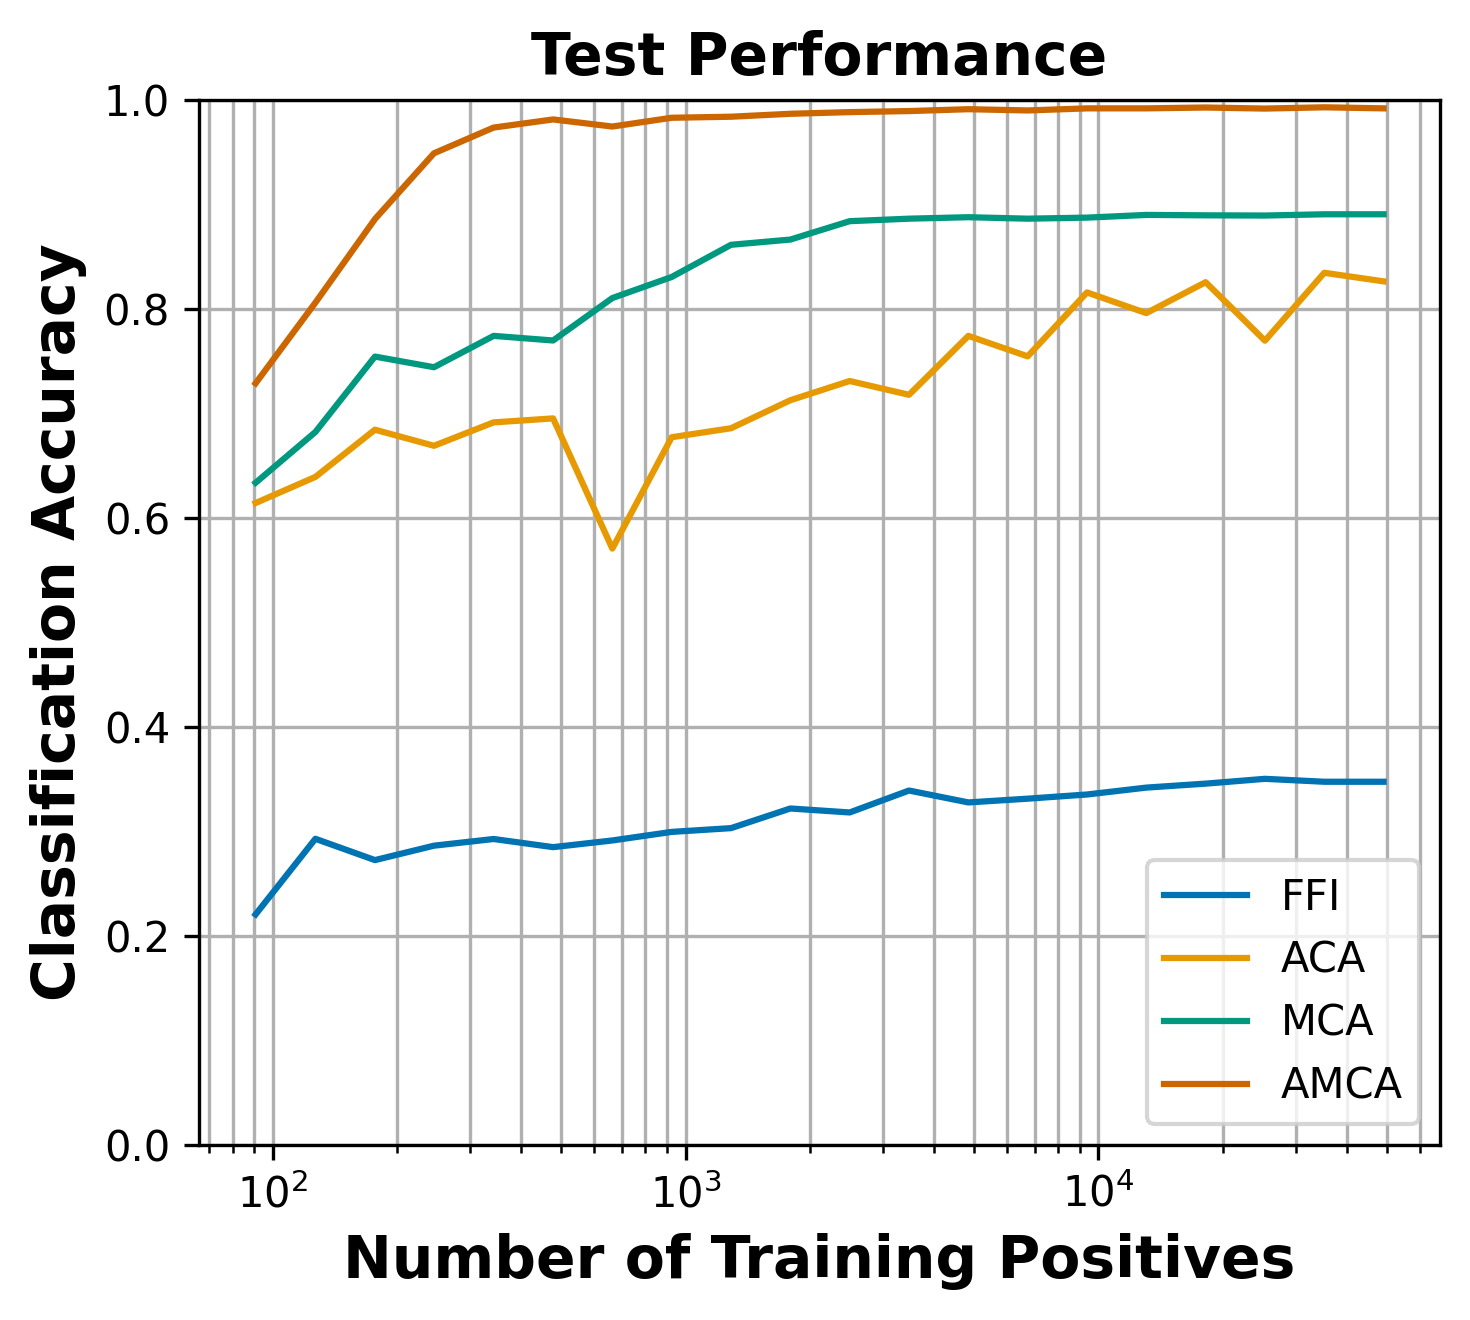

In [124]:
accuracy.to_csv("Data/dPCR_accuracy.csv")
accuracy = pd.read_csv('Data/dPCR_accuracy.csv')

methods = ['FFI', 'ACA', 'MCA', 'AMCA']

fig, ax = plt.subplots(1, 1, figsize=(5, 4.5), dpi=300)

ax.set_title('Test Performance', fontsize=14, weight='bold')
for i, method in enumerate(methods):
    df_ = accuracy[accuracy['Method'] == method]
    
    sns.lineplot(x="TrainSize", y="Accuracy", 
                 data=df_[df_['Train/Test'] == 'Test'], 
                 label=method, ci='sd', ax=ax)

ax.set_ylabel('Classification Accuracy', fontsize=14, weight='bold')
ax.set_xlabel('Number of Training Positives', fontsize=14, weight='bold')
ax.set_ylim((0., 1.0))
ax.set_xscale('log')
ax.grid(which="both", axis="both")
ax.get_legend()

# plt.subplots_adjust(wspace=0.2)
plt.tight_layout()
plt.savefig('Images/dPCR_Effect_of_Volume.pdf')
plt.show()